In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

dict_keys(['inputs', 'clean_labels', 'noisy_labels', 'unitary', 'noise_type', 'noise_level', 'circuit_code', 'qubits', 'num_samples', 'fidelity'])
inputs shape: (2000, 64), labels shape: (2000, 64), unitary matrix shape: (64, 64)
train inputs shape: (1500, 64), train labels shape: (1500, 64)
test inputs shape: (500, 64), test labels shape: (500, 64)
Using device: cuda

Training set size: 1500 samples
Batch size: 32
Batches per epoch: 47
Total iterations for 400 epochs: 18800

Training model with 0 hidden layers
Initial fidelity: 0.000341
Epoch 1/300
  Epoch 1 - Loss: 0.031302, Fidelity: 0.000302
Epoch 2/300
  Epoch 2 - Loss: 0.031128, Fidelity: 0.000378
Epoch 3/300
  Epoch 3 - Loss: 0.030953, Fidelity: 0.000570
Epoch 4/300
  Epoch 4 - Loss: 0.030778, Fidelity: 0.000877
Epoch 5/300
  Epoch 5 - Loss: 0.030606, Fidelity: 0.001300
Epoch 6/300
  Epoch 6 - Loss: 0.030433, Fidelity: 0.001838
Epoch 7/300
  Epoch 7 - Loss: 0.030259, Fidelity: 0.002492
Epoch 8/300
  Epoch 8 - Loss: 0.030086, Fid

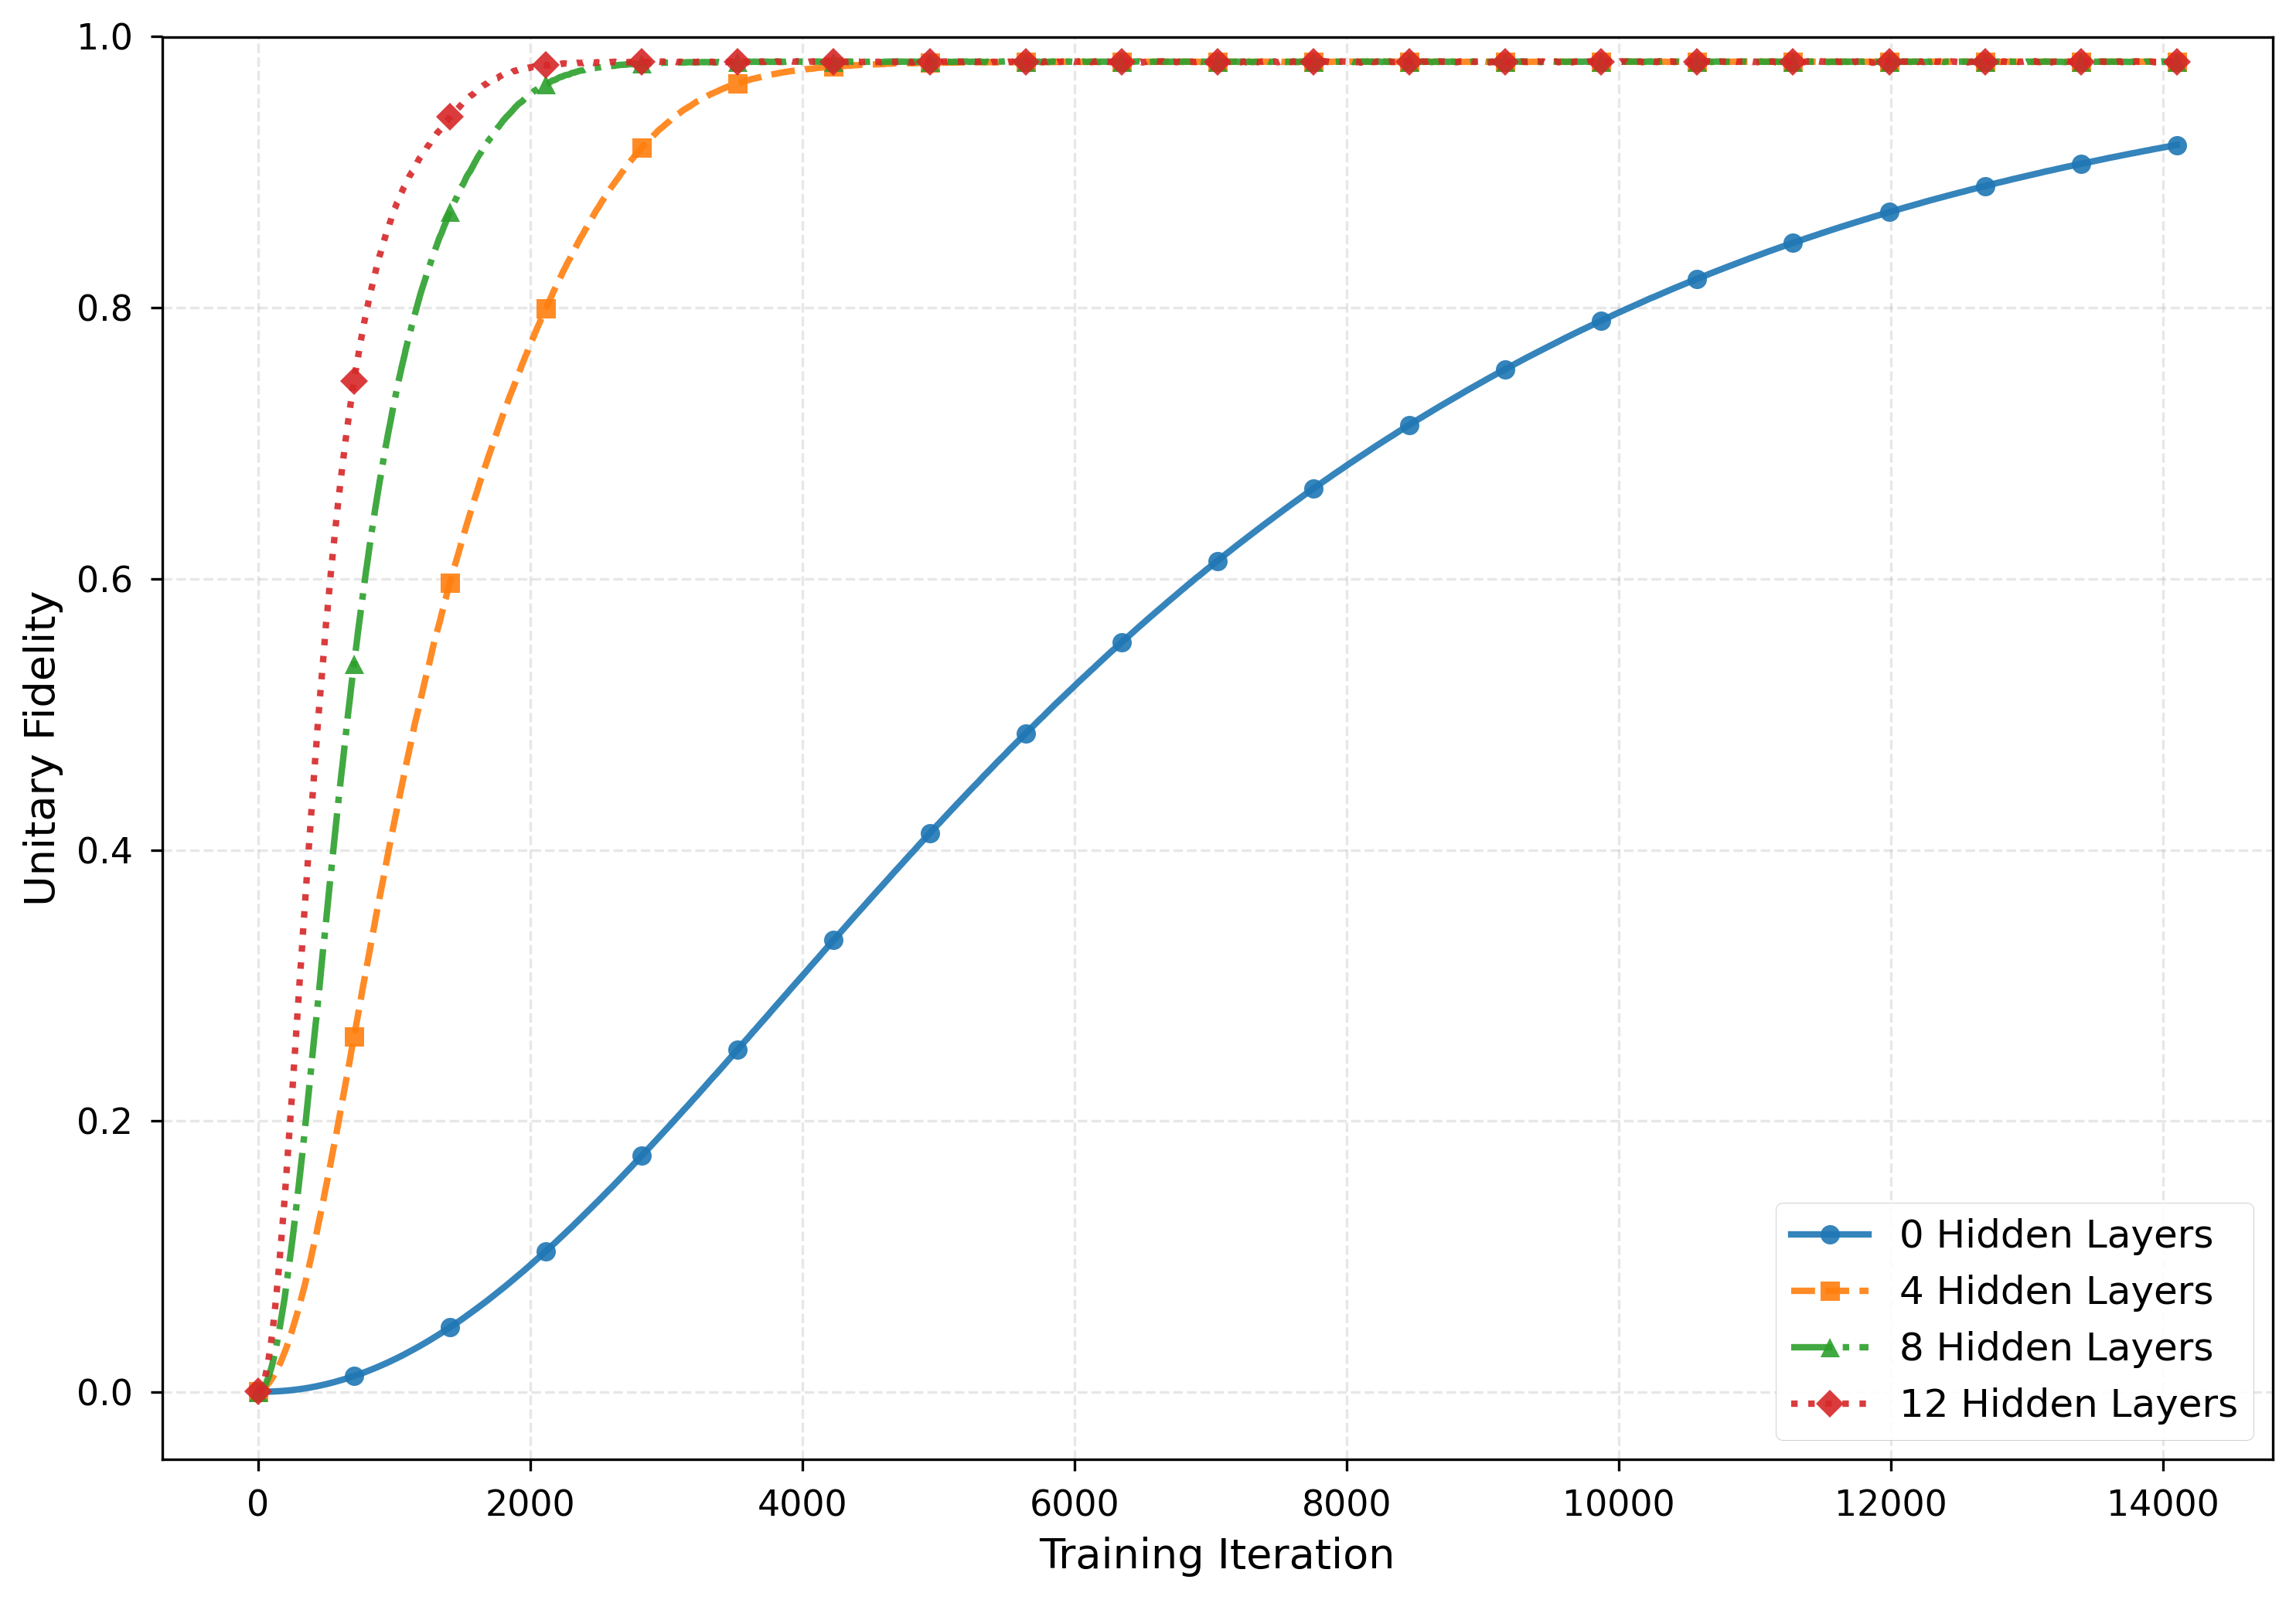


SUMMARY OF RESULTS
Hidden Layers   Final Fidelity  Max Fidelity    Iterations to 0.99   Total Iterations    
--------------------------------------------------------------------------------
0               0.920139        0.920139        Not reached          14101               
4               0.981567        0.981733        Not reached          14101               
8               0.981541        0.981912        Not reached          14101               
12              0.981591        0.982013        Not reached          14101               

Detailed analysis plots saved as 'detailed_convergence_analysis.png'


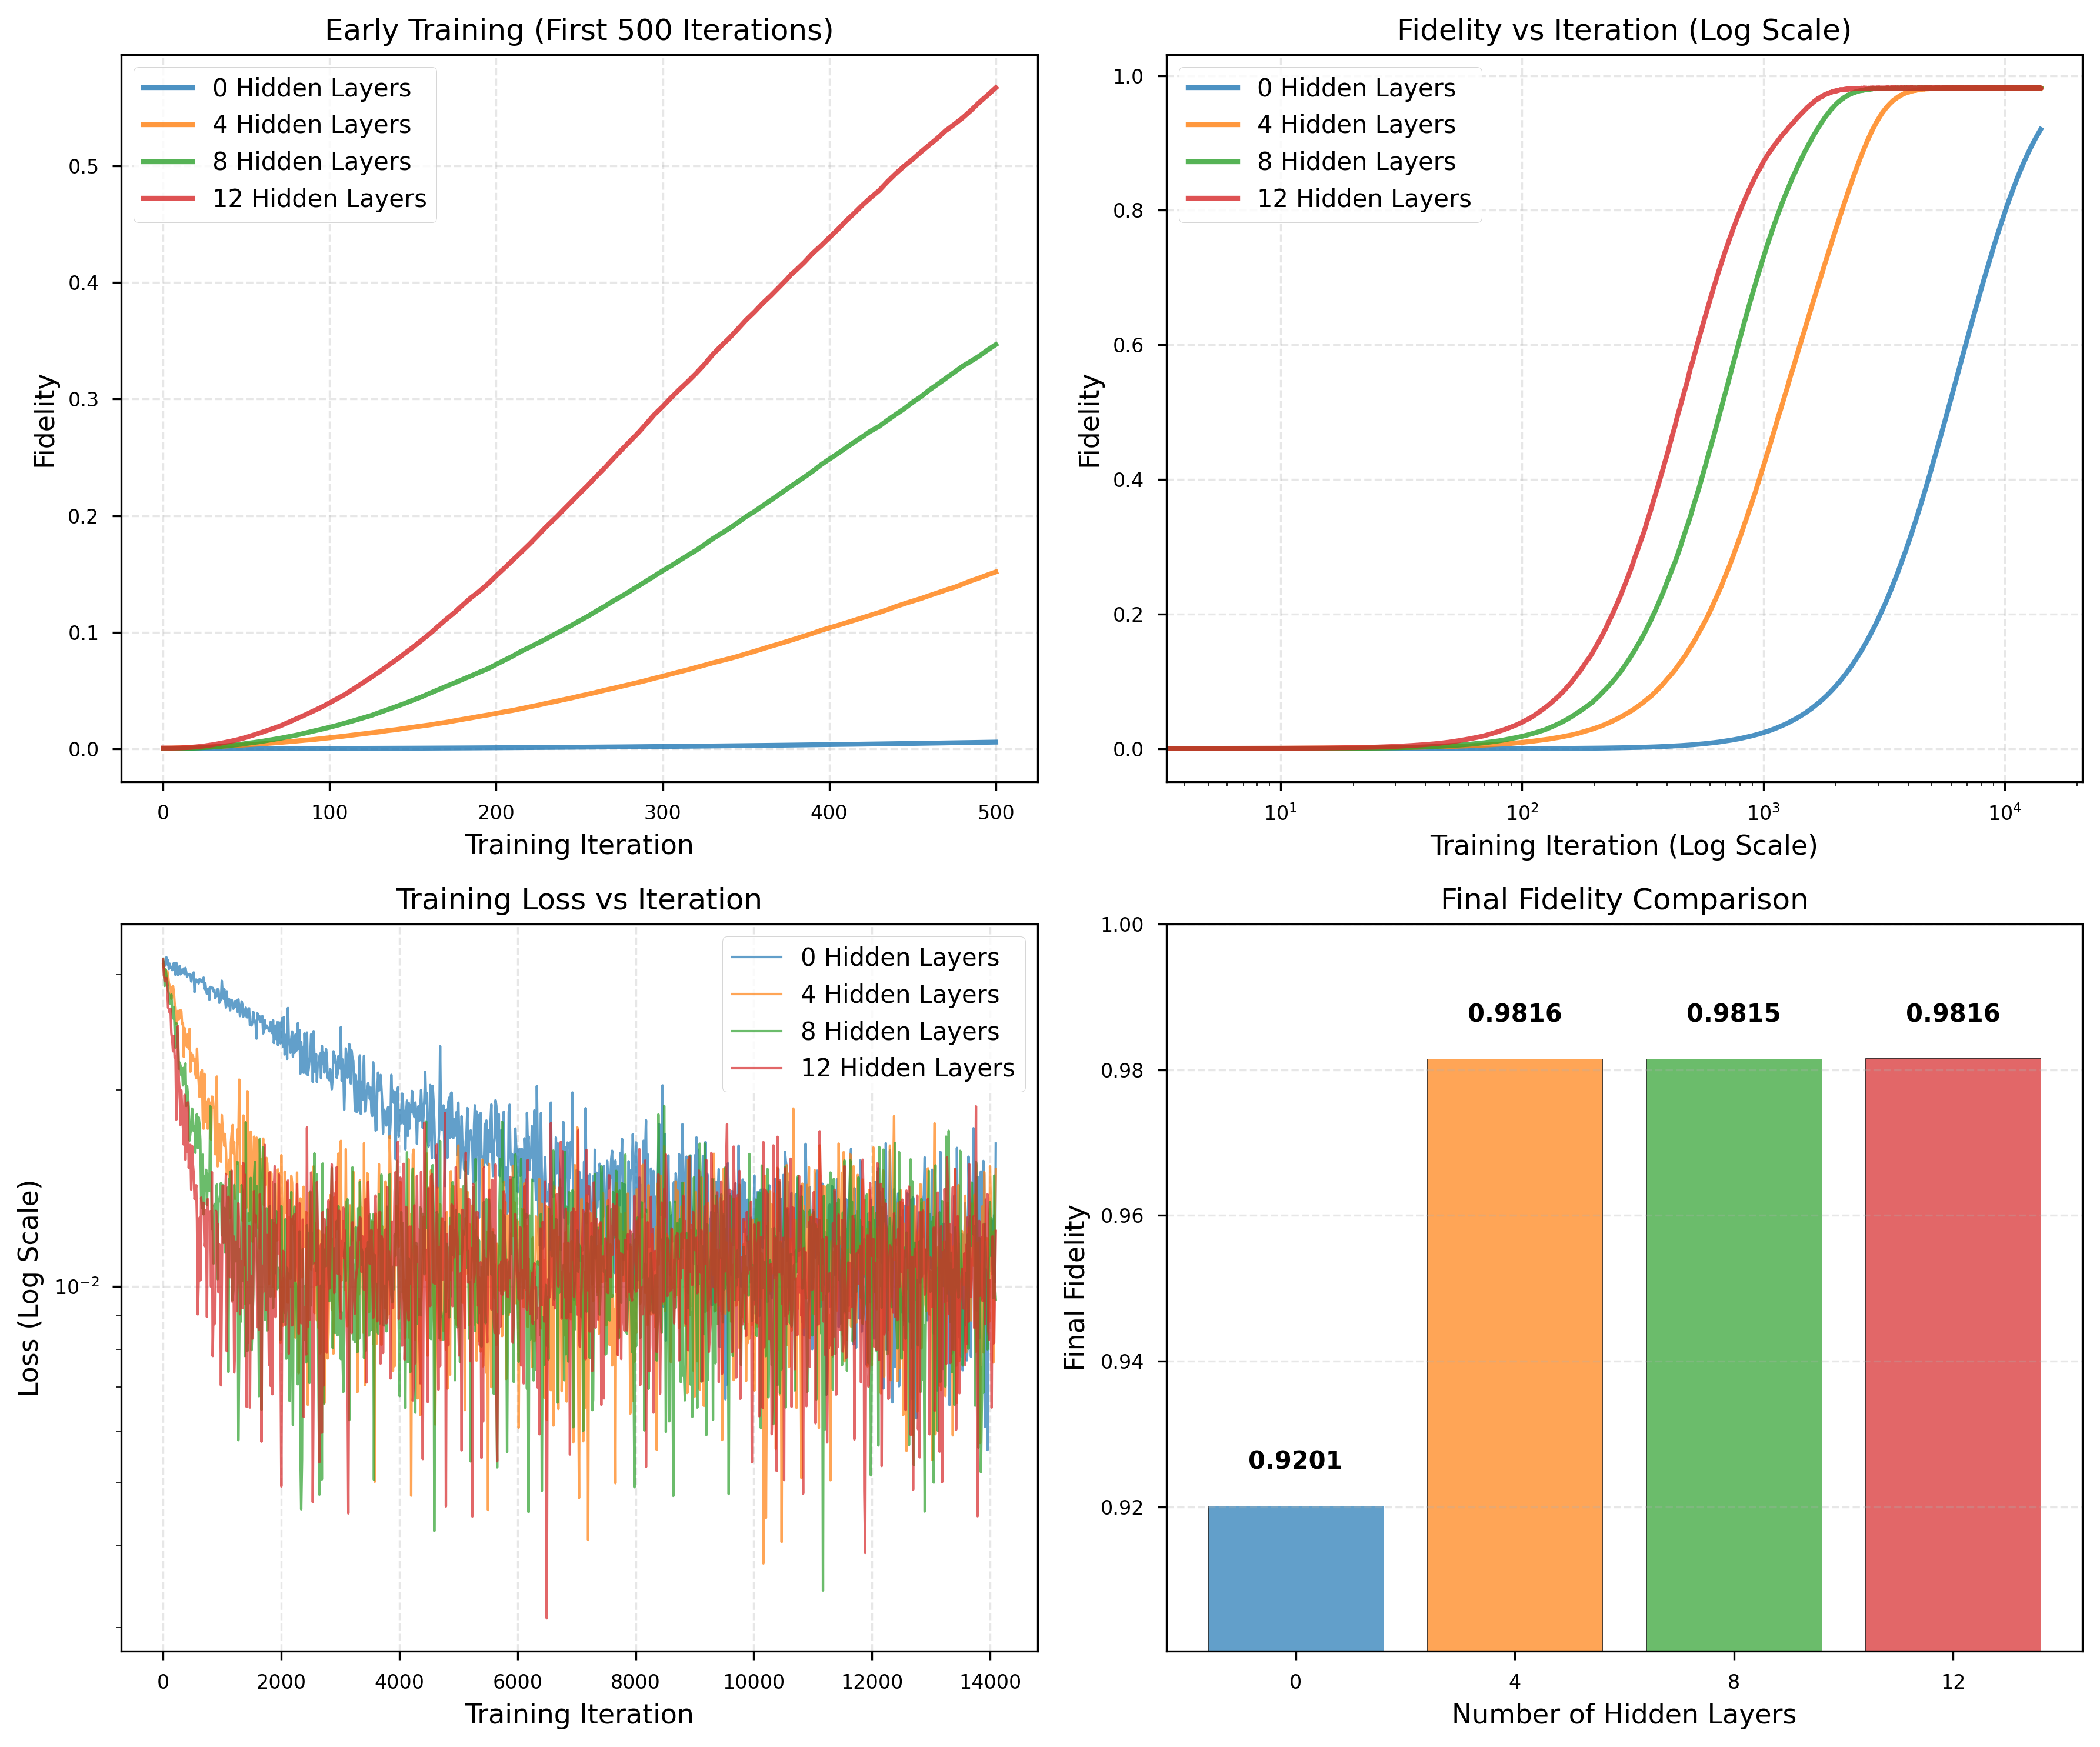


ANALYSIS:

0 Hidden Layers:
  • Initial Fidelity: 0.000341
  • Final Fidelity: 0.920139
  • Maximum Fidelity: 0.920139
  • Total Improvement: 0.919798
  • Iterations to 90% of max: 10750
  • Tracking points: 3061

4 Hidden Layers:
  • Initial Fidelity: 0.000527
  • Final Fidelity: 0.981567
  • Maximum Fidelity: 0.981733
  • Total Improvement: 0.981039
  • Iterations to 90% of max: 2565
  • Tracking points: 3061

8 Hidden Layers:
  • Initial Fidelity: 0.000139
  • Final Fidelity: 0.981541
  • Maximum Fidelity: 0.981912
  • Total Improvement: 0.981403
  • Iterations to 90% of max: 1475
  • Tracking points: 3061

12 Hidden Layers:
  • Initial Fidelity: 0.000713
  • Final Fidelity: 0.981591
  • Maximum Fidelity: 0.982013
  • Total Improvement: 0.980879
  • Iterations to 90% of max: 1050
  • Tracking points: 3061

CONCLUSION:
Best performing architecture: 12 hidden layers (fidelity: 0.981591)

Convergence Rate Analysis:
  0 Hidden Layers: 0.065232 fidelity gain per 1000 iterations
  4 Hidd

In [5]:
import numpy as np
import pickle
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Load dataset
complex_numbers = True
# circuit_code = '9_8_6'
# phi_samples = 2000
# qubits = 3
# samples = 2000

if complex_numbers:
    dataset_file = 'qdataset_9_6q_2000s_phase_damping_noise0.04.pickle'
else:
    dataset_file = 'q_dataset.pickle'

with open(dataset_file, 'rb') as df:
    data = pickle.load(df)

print(data.keys())
inputs = data.get('inputs')
labels = data.get('noisy_labels')
unitary_matrix = data.get('unitary')
print('inputs shape: {}, labels shape: {}, unitary matrix shape: {}'.format(
    inputs.shape, labels.shape, unitary_matrix.shape))

# Shuffle dataset
indexes = np.arange(inputs.shape[0])
np.random.shuffle(indexes)
reshaped_inputs = inputs[indexes]
labels = labels[indexes]

# Split test and train data
split_ratio = 0.25
num_test_samples = int(split_ratio * inputs.shape[0])
test_x, test_y = reshaped_inputs[:num_test_samples], labels[:num_test_samples]
train_x, train_y = reshaped_inputs[num_test_samples:], labels[num_test_samples:]

print('train inputs shape: {}, train labels shape: {}'.format(train_x.shape, train_y.shape))
print('test inputs shape: {}, test labels shape: {}'.format(test_x.shape, test_y.shape))

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert true unitary to tensor
U_true = torch.tensor(unitary_matrix, dtype=torch.complex128).to(device)

# Define utility functions
def random_unitary_matrix(N, dtype=torch.complex128, device='cpu'):
    """Generate a random unitary matrix."""
    real = torch.randn((N, N), dtype=torch.float64, device=device)
    imag = torch.randn((N, N), dtype=torch.float64, device=device)
    A = torch.complex(real, imag)
    Q, R = torch.linalg.qr(A)
    Q = Q @ torch.diag(R.diag() / torch.abs(R.diag()).clamp(min=1e-12)).conj()
    return Q.to(dtype)

class QComplexLinear(nn.Module):
    """Complex-valued linear layer with unitary initialization."""
    def __init__(self, in_features, out_features):
        super(QComplexLinear, self).__init__()
        self.fc = nn.Linear(in_features, out_features, bias=False, dtype=torch.complex128)
        
        # Initialize as unitary if square matrix
        if in_features == out_features:
            with torch.no_grad():
                unitary = random_unitary_matrix(in_features, device=self.fc.weight.device, dtype=torch.complex128)
                self.fc.weight.copy_(unitary)
    
    def forward(self, input):
        return self.fc(input)
    
    def get_weight_matrix(self):
        """Get the weight matrix of this layer."""
        return self.fc.weight.data.clone()

class UnitaryComplexNet(nn.Module):
    """Unitary network with variable number of hidden layers."""
    def __init__(self, input_size, num_layers=1):
        super(UnitaryComplexNet, self).__init__()
        self.input_size = input_size
        self.num_layers = num_layers
        
        # Create hidden layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(QComplexLinear(input_size, input_size))
        
        # Output layer
        self.output_layer = QComplexLinear(input_size, input_size)
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.output_layer(x)
        return x
    
    def get_unitary(self):
        """Get the overall unitary matrix of the network."""
        if self.num_layers == 0:
            return self.output_layer.get_weight_matrix()
        
        # Compute product of all weight matrices (from first to last)
        U = self.layers[0].get_weight_matrix()
        for i in range(1, len(self.layers)):
            U = self.layers[i].get_weight_matrix() @ U
        U = self.output_layer.get_weight_matrix() @ U
        return U

class ComplexMSELoss(nn.Module):
    """MSE loss for complex numbers."""
    def __init__(self):
        super(ComplexMSELoss, self).__init__()
    
    def forward(self, y_pred, y_true):
        real_loss = torch.mean((y_pred.real - y_true.real) ** 2)
        imag_loss = torch.mean((y_pred.imag - y_true.imag) ** 2)
        return real_loss + imag_loss

def unitary_fidelity(U_true, U_learned):
    """Calculate fidelity between two unitaries."""
    N = U_true.shape[0]
    U_true_dag = U_true.conj().T
    trace_val = torch.trace(U_true_dag @ U_learned)
    fidelity = (torch.abs(trace_val) ** 2) / (N ** 2)
    return fidelity.item()

def prepare_data(train_x, train_y, test_x, test_y, batch_size=32):
    """Prepare data loaders."""
    train_x = torch.tensor(train_x, dtype=torch.complex128)
    train_y = torch.tensor(train_y, dtype=torch.complex128)
    test_x = torch.tensor(test_x, dtype=torch.complex128)
    test_y = torch.tensor(test_y, dtype=torch.complex128)
    
    train_dataset = TensorDataset(train_x, train_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(test_x, test_y)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    return train_loader, val_loader

def train_model(num_hidden_layers, train_loader, val_loader, epochs=400, lr=0.8, track_interval=1):
    """Train a model with given number of hidden layers and return fidelity history at each iteration."""
    print(f"\n{'='*60}")
    print(f"Training model with {num_hidden_layers} hidden layers")
    print(f"{'='*60}")
    
    # Create model
    input_size = train_x.shape[1]
    model = UnitaryComplexNet(input_size=input_size, num_layers=num_hidden_layers).to(device)
    
    # Loss function
    loss_fn = ComplexMSELoss()
    
    # Lists to track metrics
    iteration_losses = []
    iteration_fidelities = []
    iterations = []
    iteration_counter = 0
    
    # Calculate initial fidelity
    model.eval()
    with torch.no_grad():
        U_learned = model.get_unitary()
        initial_fidelity = unitary_fidelity(U_true, U_learned)
    iteration_fidelities.append(initial_fidelity)
    iterations.append(0)
    iteration_counter += 1
    model.train()
    
    print(f"Initial fidelity: {initial_fidelity:.6f}")
    
    # Training loop
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        batch_losses = []
        
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            
            # Backward pass and Cayley transform update
            model.zero_grad()
            loss.backward()
            
            with torch.no_grad():
                for layer in model.layers + [model.output_layer]:
                    W = layer.fc.weight
                    G = layer.fc.weight.grad
                    
                    if G is not None:
                        # Cayley Transform Update
                        A = G @ W.conj().T - W @ G.conj().T
                        N = W.shape[0]
                        I = torch.eye(N, dtype=torch.complex128, device=W.device)
                        term = (lr / 2) * A
                        inv_term = torch.inverse(I + term)
                        W_updated = inv_term @ (I - term) @ W
                        
                        layer.fc.weight.data = W_updated
                        layer.fc.weight.grad = None
            
            iteration_counter += 1
            batch_loss = loss.item()
            iteration_losses.append(batch_loss)
            batch_losses.append(batch_loss)
            
            # Calculate fidelity at specified intervals
            if iteration_counter % track_interval == 0:
                model.eval()
                with torch.no_grad():
                    U_learned = model.get_unitary()
                    fidelity = unitary_fidelity(U_true, U_learned)
                model.train()
                
                iteration_fidelities.append(fidelity)
                iterations.append(iteration_counter)
        
        # Calculate epoch statistics
        avg_epoch_loss = sum(batch_losses) / len(batch_losses) if batch_losses else 0
        
        # Get fidelity at the end of the epoch
        model.eval()
        with torch.no_grad():
            U_learned = model.get_unitary()
            epoch_fidelity = unitary_fidelity(U_true, U_learned)
        model.train()
        
        # If we haven't tracked this iteration yet, add it
        if iteration_counter not in iterations:
            iteration_fidelities.append(epoch_fidelity)
            iterations.append(iteration_counter)
        
        print(f"  Epoch {epoch+1} - Loss: {avg_epoch_loss:.6f}, Fidelity: {epoch_fidelity:.6f}")
    
    # Get final fidelity
    model.eval()
    with torch.no_grad():
        U_learned = model.get_unitary()
        final_fidelity = unitary_fidelity(U_true, U_learned)
    
    print(f"\nTraining completed!")
    print(f"Final Fidelity: {final_fidelity:.6f}")
    print(f"Total iterations: {iteration_counter}")
    print(f"Fidelity tracked at {len(iterations)} points")
    
    return {
        'fidelity_history': iteration_fidelities,
        'iteration_history': iterations,
        'final_fidelity': final_fidelity,
        'loss_history': iteration_losses,
        'total_iterations': iteration_counter
    }

# Prepare data loaders
batch_size = 32
train_loader, val_loader = prepare_data(train_x, train_y, test_x, test_y, batch_size)

print(f"\nTraining set size: {len(train_x)} samples")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Total iterations for 400 epochs: {400 * len(train_loader)}")

# Define hidden layers to test
hidden_layers_list = [0, 4, 8, 12]
results = {}
track_interval = 5  # Track fidelity every 10 iterations to reduce computation

# Train models for different numbers of hidden layers
for num_hidden in hidden_layers_list:
    results[num_hidden] = train_model(
        num_hidden, 
        train_loader, 
        val_loader, 
        epochs=300, 
        lr=0.5,
        track_interval=track_interval
    )

# Create paper-ready plot for Fidelity vs Iteration
plt.style.use('seaborn-v0_8-paper')  # Professional style
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Define colors and markers for different number of hidden layers
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
markers = ['o', 's', '^', 'D']  # Circle, Square, Triangle, Diamond
line_styles = ['-', '--', '-.', ':']

# Plot fidelity vs iteration for each number of hidden layers
for idx, num_hidden in enumerate(hidden_layers_list):
    iterations = results[num_hidden]['iteration_history']
    fidelities = results[num_hidden]['fidelity_history']
    
    # Plot line with markers (show fewer markers for clarity)
    marker_every = max(1, len(iterations) // 20)  # Show about 20 markers
    
    ax.plot(iterations, fidelities, 
            label=f'{num_hidden} Hidden Layers',
            color=colors[idx % len(colors)],
            marker=markers[idx % len(markers)],
            markersize=6,
            markevery=marker_every,
            linewidth=2,
            linestyle=line_styles[idx % len(line_styles)],
            alpha=0.9)

# Customize plot
ax.set_xlabel('Training Iteration', fontsize=13)
ax.set_ylabel('Unitary Fidelity', fontsize=13)
#ax.set_title('Fidelity vs Training Iteration for Different Network Depths', fontsize=14, pad=20)

# Add grid
ax.grid(True, linestyle='--', alpha=0.3, which='both')
ax.tick_params(axis='both', labelsize=11)

# Set y-axis limits
all_fidelities = []
for num_hidden in hidden_layers_list:
    all_fidelities.extend(results[num_hidden]['fidelity_history'])
min_fid = min(all_fidelities) if all_fidelities else 0
max_fid = max(all_fidelities) if all_fidelities else 1

# Adjust y-axis limits with some padding
if min_fid > 0.9:
    ax.set_ylim([0.9, 1.0])
elif min_fid > 0.8:
    ax.set_ylim([0.8, 1.0])
elif min_fid > 0.7:
    ax.set_ylim([0.7, 1.0])
else:
    ax.set_ylim([min_fid - 0.05, 1.0])

# Add legend
ax.legend(fontsize=12, loc='best', framealpha=0.9)

# Adjust layout
plt.tight_layout()

# Save as TIFF (paper-ready format)
plt.savefig('fidelity_vs_iteration_hidden_layers.tiff', format='tiff', dpi=300, 
            bbox_inches='tight', pad_inches=0.1)
print("\nPlot saved as 'fidelity_vs_iteration_hidden_layers.tiff'")

# Also save as PNG for quick viewing
plt.savefig('fidelity_vs_iteration_hidden_layers.png', format='png', dpi=300,
            bbox_inches='tight', pad_inches=0.1)

# Show plot
plt.show()

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(f"{'Hidden Layers':<15} {'Final Fidelity':<15} {'Max Fidelity':<15} {'Iterations to 0.99':<20} {'Total Iterations':<20}")
print("-"*80)

for num_hidden in hidden_layers_list:
    final_fid = results[num_hidden]['final_fidelity']
    max_fid = max(results[num_hidden]['fidelity_history'])
    total_iters = results[num_hidden]['total_iterations']
    
    # Find iteration when fidelity first reaches 0.99
    iters_to_99 = None
    for iter_val, fid in zip(results[num_hidden]['iteration_history'], results[num_hidden]['fidelity_history']):
        if fid >= 0.99:
            iters_to_99 = iter_val
            break
    
    iters_str = str(iters_to_99) if iters_to_99 is not None else "Not reached"
    
    print(f"{num_hidden:<15} {final_fid:<15.6f} {max_fid:<15.6f} {iters_str:<20} {total_iters:<20}")

print("="*80)

# Create additional plot for convergence analysis
fig2, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
axes = axes.flatten()

# Plot 1: Zoom on early iterations (first 500 iterations)
for idx, num_hidden in enumerate(hidden_layers_list):
    iterations = results[num_hidden]['iteration_history']
    fidelities = results[num_hidden]['fidelity_history']
    
    # Filter for first 500 iterations
    early_iters = []
    early_fids = []
    for iter_val, fid in zip(iterations, fidelities):
        if iter_val <= 500:
            early_iters.append(iter_val)
            early_fids.append(fid)
    
    if early_iters:
        axes[0].plot(early_iters, early_fids, 
                    label=f'{num_hidden} Hidden Layers',
                    color=colors[idx % len(colors)],
                    linewidth=2,
                    alpha=0.8)

axes[0].set_xlabel('Training Iteration', fontsize=11)
axes[0].set_ylabel('Fidelity', fontsize=11)
axes[0].set_title('Early Training (First 500 Iterations)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(fontsize=10)

# Plot 2: Log scale for iterations
for idx, num_hidden in enumerate(hidden_layers_list):
    iterations = results[num_hidden]['iteration_history']
    fidelities = results[num_hidden]['fidelity_history']
    
    axes[1].plot(iterations, fidelities, 
                label=f'{num_hidden} Hidden Layers',
                color=colors[idx % len(colors)],
                linewidth=2,
                alpha=0.8)

axes[1].set_xlabel('Training Iteration (Log Scale)', fontsize=11)
axes[1].set_ylabel('Fidelity', fontsize=11)
axes[1].set_title('Fidelity vs Iteration (Log Scale)', fontsize=12)
axes[1].set_xscale('log')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(fontsize=10)

# Plot 3: Loss vs Iteration (log scale for loss)
for idx, num_hidden in enumerate(hidden_layers_list):
    loss_history = results[num_hidden]['loss_history']
    # Take every 100th point for clarity
    subsample_factor = max(1, len(loss_history) // 1000)
    loss_iters = list(range(0, len(loss_history), subsample_factor))
    loss_vals = [loss_history[i] for i in loss_iters]
    
    axes[2].plot(loss_iters, loss_vals, 
                label=f'{num_hidden} Hidden Layers',
                color=colors[idx % len(colors)],
                linewidth=1,
                alpha=0.7)

axes[2].set_xlabel('Training Iteration', fontsize=11)
axes[2].set_ylabel('Loss (Log Scale)', fontsize=11)
axes[2].set_title('Training Loss vs Iteration', fontsize=12)
axes[2].set_yscale('log')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend(fontsize=10)

# Plot 4: Final fidelity comparison
final_fidelities = [results[num_hidden]['final_fidelity'] for num_hidden in hidden_layers_list]
bars = axes[3].bar(range(len(hidden_layers_list)), final_fidelities, 
                  color=colors[:len(hidden_layers_list)], alpha=0.7, edgecolor='black')
axes[3].set_xlabel('Number of Hidden Layers', fontsize=11)
axes[3].set_ylabel('Final Fidelity', fontsize=11)
axes[3].set_title('Final Fidelity Comparison', fontsize=12)
axes[3].set_xticks(range(len(hidden_layers_list)))
axes[3].set_xticklabels([str(h) for h in hidden_layers_list])
axes[3].grid(True, axis='y', linestyle='--', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(final_fidelities):
    axes[3].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# Adjust y-limits for bar plot
axes[3].set_ylim([min(final_fidelities) - 0.02, min(1.0, max(final_fidelities) + 0.02)])

plt.tight_layout()
plt.savefig('detailed_convergence_analysis.png', dpi=300, bbox_inches='tight')
print("\nDetailed analysis plots saved as 'detailed_convergence_analysis.png'")
plt.show()

# Additional analysis
print("\n" + "="*80)
print("ANALYSIS:")
print("="*80)

for num_hidden in hidden_layers_list:
    fidelities = results[num_hidden]['fidelity_history']
    iterations = results[num_hidden]['iteration_history']
    
    if len(fidelities) > 1:
        # Calculate convergence metrics
        initial_fid = fidelities[0]
        final_fid = results[num_hidden]['final_fidelity']
        
        # Find iteration where fidelity reaches 90% of maximum improvement
        max_fid = max(fidelities)
        target_fid = initial_fid + 0.9 * (max_fid - initial_fid)
        
        iters_to_90pct = None
        for iter_val, fid in zip(iterations, fidelities):
            if fid >= target_fid:
                iters_to_90pct = iter_val
                break
        
        print(f"\n{num_hidden} Hidden Layers:")
        print(f"  • Initial Fidelity: {initial_fid:.6f}")
        print(f"  • Final Fidelity: {final_fid:.6f}")
        print(f"  • Maximum Fidelity: {max_fid:.6f}")
        print(f"  • Total Improvement: {final_fid - initial_fid:.6f}")
        if iters_to_90pct:
            print(f"  • Iterations to 90% of max: {iters_to_90pct}")
        print(f"  • Tracking points: {len(fidelities)}")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)

# Find best performing architecture
best_fid = -1
best_arch = None
for num_hidden in hidden_layers_list:
    if results[num_hidden]['final_fidelity'] > best_fid:
        best_fid = results[num_hidden]['final_fidelity']
        best_arch = num_hidden

print(f"Best performing architecture: {best_arch} hidden layers (fidelity: {best_fid:.6f})")

# Calculate convergence rate
print("\nConvergence Rate Analysis:")
for num_hidden in hidden_layers_list:
    fidelities = results[num_hidden]['fidelity_history']
    if len(fidelities) >= 2:
        # Calculate average improvement per 100 iterations
        early_fid = fidelities[min(10, len(fidelities)-1)]
        late_fid = fidelities[-1]
        total_iters = results[num_hidden]['iteration_history'][-1]
        
        if total_iters > 0:
            improvement_rate = (late_fid - early_fid) / total_iters * 1000  # per 1000 iterations
            print(f"  {num_hidden} Hidden Layers: {improvement_rate:.6f} fidelity gain per 1000 iterations")

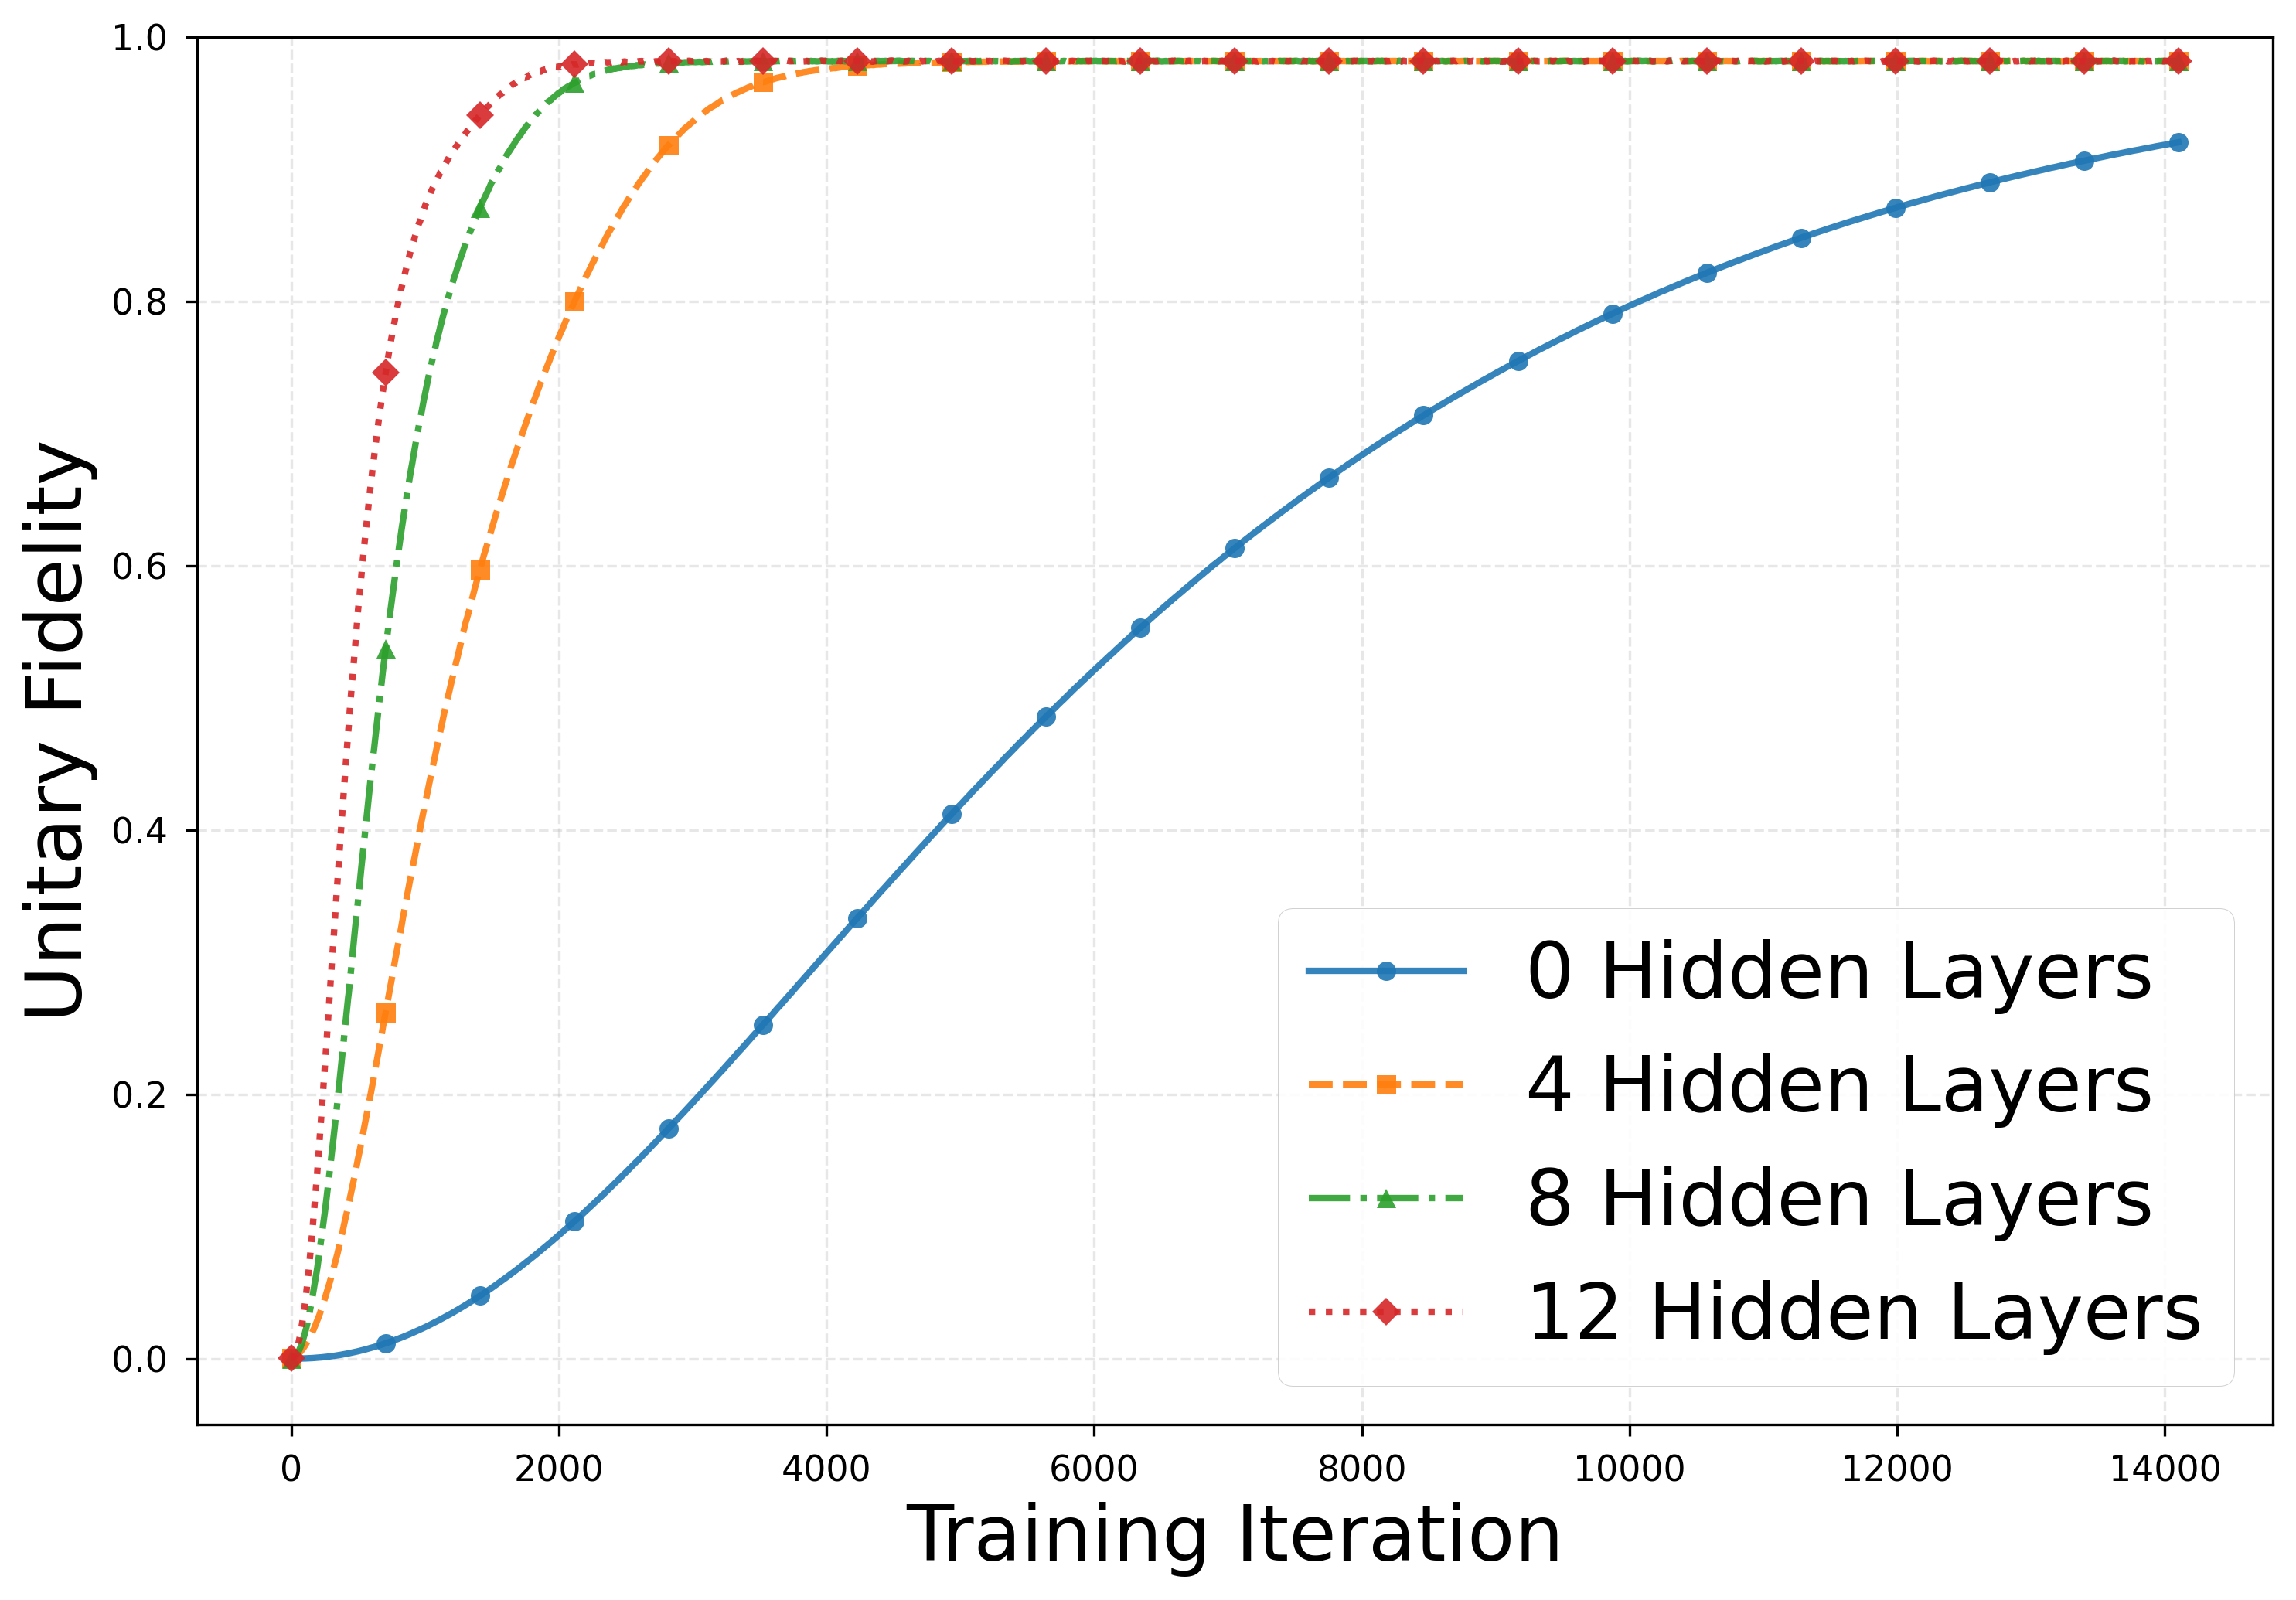

In [12]:
# Create paper-ready plot for Fidelity vs Iteration
plt.style.use('seaborn-v0_8-paper')  # Professional style
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Define colors and markers for different number of hidden layers
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
markers = ['o', 's', '^', 'D']  # Circle, Square, Triangle, Diamond
line_styles = ['-', '--', '-.', ':']

# Plot fidelity vs iteration for each number of hidden layers
for idx, num_hidden in enumerate(hidden_layers_list):
    iterations = results[num_hidden]['iteration_history']
    fidelities = results[num_hidden]['fidelity_history']
    
    # Plot line with markers (show fewer markers for clarity)
    marker_every = max(1, len(iterations) // 20)  # Show about 20 markers
    
    ax.plot(iterations, fidelities, 
            label=f'{num_hidden} Hidden Layers',
            color=colors[idx % len(colors)],
            marker=markers[idx % len(markers)],
            markersize=6,
            markevery=marker_every,
            linewidth=2,
            linestyle=line_styles[idx % len(line_styles)],
            alpha=0.9)

# Customize plot
ax.set_xlabel('Training Iteration', fontsize=24)
ax.set_ylabel('Unitary Fidelity', fontsize=24)
#ax.set_title('Fidelity vs Training Iteration for Different Network Depths', fontsize=14, pad=20)

# Add grid
ax.grid(True, linestyle='--', alpha=0.3, which='both')
ax.tick_params(axis='both', labelsize=11)

# Set y-axis limits
all_fidelities = []
for num_hidden in hidden_layers_list:
    all_fidelities.extend(results[num_hidden]['fidelity_history'])
min_fid = min(all_fidelities) if all_fidelities else 0
max_fid = max(all_fidelities) if all_fidelities else 1

# Adjust y-axis limits with some padding
if min_fid > 0.9:
    ax.set_ylim([0.9, 1.0])
elif min_fid > 0.8:
    ax.set_ylim([0.8, 1.0])
elif min_fid > 0.7:
    ax.set_ylim([0.7, 1.0])
else:
    ax.set_ylim([min_fid - 0.05, 1.0])

# Add legend
ax.legend(fontsize=24, loc='best', framealpha=0.9)


# Adjust layout
plt.tight_layout()

# # Save as TIFF (paper-ready format)
# plt.savefig('fidelity_vs_iteration_hidden_layers.tiff', format='tiff', dpi=300, 
#             bbox_inches='tight', pad_inches=0.1)
# print("\nPlot saved as 'fidelity_vs_iteration_hidden_layers.tiff'")

# Also save as PNG for quick viewing
plt.savefig('fidelity_vs_iteration_hidden_layers.png', format='png', dpi=300,
            bbox_inches='tight', pad_inches=0.1)

# Show plot
plt.show()